# 01 - Data Extraction and Initial Inspection

**Project:** Uber Data Visualization and Analysis  
**Stage:** Step 1 - Raw Data Review  
**Dataset:** `data/raw/uber_raw_dataset.csv`

This notebook verifies the raw extract before cleaning begins.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Project root not found from current working directory.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())


RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'uber_raw_dataset.csv'
print(f'Project root : {PROJECT_ROOT}')
print(f'Raw file     : {RAW_PATH}')


Project root : /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis
Raw file     : /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis/data/raw/uber_raw_dataset.csv


## Load Raw Dataset


In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Rows    : {df_raw.shape[0]:,}')
print(f'Columns : {df_raw.shape[1]}')
display(df_raw.head())


Rows    : 50,000
Columns : 14


,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time
0,1,8270,10683,San Francisco,37.17,-77.59,37.17,-77.62,2.97,10.71,Completed,Wallet,2023-01-01 00:00:00,2023-01-01 00:08:54.600000000
1,2,1860,44743,Boston,38.90,-108.58,38.94,-108.56,8.43,22.41,Completed,UPI,2023-01-01 00:01:00,2023-01-01 00:26:17.400000000
2,3,6390,75839,San Francisco,38.81,-89.94,38.82,-89.90,5.46,12.91,Completed,Cash,2023-01-01 00:02:00,2023-01-01 00:18:22.800000000
3,4,6191,22189,New York,37.30,-75.33,37.30,-75.32,6.61,15.70,Completed,Wallet,2023-01-01 00:03:00,2023-01-01 00:22:49.800000000
4,5,6734,61104,Seattle,38.97,-121.48,38.99,-121.47,10.50,19.15,Completed,Wallet,2023-01-01 00:04:00,2023-01-01 00:35:30.000000000


## Structural Review


In [3]:
schema = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'non_null_count': df_raw.notna().sum().values,
    'unique_values': [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
})
display(schema)
df_raw.info()


,column,dtype,non_null_count,unique_values
0,trip_id,int64,50000,50000
1,driver_id,int64,50000,8963
2,rider_id,int64,50000,38352
3,city,str,50000,6
4,pickup_lat,float64,50000,50000
5,pickup_lng,float64,50000,50000
6,drop_lat,float64,50000,50000
7,drop_lng,float64,50000,50000
8,distance_km,float64,50000,1623
9,fare_amount,float64,50000,3402


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   trip_id         50000 non-null  int64  
 1   driver_id       50000 non-null  int64  
 2   rider_id        50000 non-null  int64  
 3   city            50000 non-null  str    
 4   pickup_lat      50000 non-null  float64
 5   pickup_lng      50000 non-null  float64
 6   drop_lat        50000 non-null  float64
 7   drop_lng        50000 non-null  float64
 8   distance_km     50000 non-null  float64
 9   fare_amount     50000 non-null  float64
 10  status          50000 non-null  str    
 11  payment_method  50000 non-null  str    
 12  pickup_time     50000 non-null  str    
 13  drop_time       50000 non-null  str    
dtypes: float64(6), int64(3), str(5)
memory usage: 5.3 MB


## Categorical Value Check


In [4]:
for col in ['city', 'status', 'payment_method']:
    print()
    print(col.upper())
    print(df_raw[col].value_counts(dropna=False).sort_index().to_string())



CITY
city
Boston           8454
Chicago          8345
Los Angeles      8315
New York         8247
San Francisco    8401
Seattle          8238

STATUS
status
Cancelled     4984
Completed    42540
No-Show       2476

PAYMENT_METHOD
payment_method
Card      12533
Cash      12413
UPI       12549
Wallet    12505


## Missing Values and Duplicates


In [5]:
quality_checks = pd.DataFrame({
    'metric': ['Total missing values', 'Fully duplicated rows', 'Duplicate trip_id values'],
    'value': [
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()),
        int(df_raw['trip_id'].duplicated().sum()),
    ],
})
display(quality_checks)


,metric,value
0,Total missing values,0
1,Fully duplicated rows,0
2,Duplicate trip_id values,0


## Time Coverage


,metric,value
0,Earliest pickup,2023-01-01 00:00:00
1,Latest pickup,2023-02-04 17:19:00
2,Earliest drop,2023-01-01 00:08:54.600000
3,Latest drop,2023-02-04 17:48:54.600000
4,Unique pickup dates,35


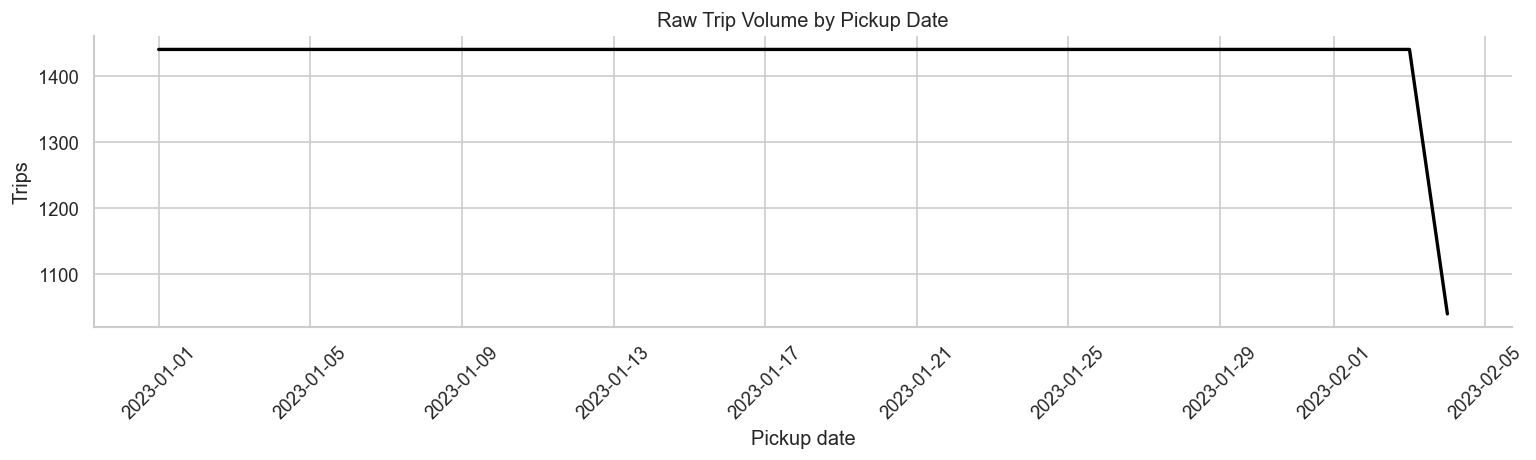

In [6]:
pickup_dt = pd.to_datetime(df_raw['pickup_time'])
drop_dt = pd.to_datetime(df_raw['drop_time'])

coverage = pd.DataFrame({
    'metric': ['Earliest pickup', 'Latest pickup', 'Earliest drop', 'Latest drop', 'Unique pickup dates'],
    'value': [pickup_dt.min(), pickup_dt.max(), drop_dt.min(), drop_dt.max(), pickup_dt.dt.date.nunique()],
})
display(coverage)

daily_trip_counts = pickup_dt.dt.date.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_trip_counts.index, daily_trip_counts.values, color='black', linewidth=2)
ax.set_title('Raw Trip Volume by Pickup Date')
ax.set_xlabel('Pickup date')
ax.set_ylabel('Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Suitability Summary


In [7]:
start_date = pickup_dt.min().date()
end_date = pickup_dt.max().date()
suitability = pd.DataFrame({
    'criterion': [
        'Sufficient row volume',
        'Trip identifier uniqueness',
        'Missing values',
        'Multiple cities present',
        'Timestamp coverage',
    ],
    'assessment': [
        'Pass - 50,000 raw trips available',
        'Pass - trip_id is unique in the raw file',
        'Pass - no null values detected',
        f"Pass - {df_raw['city'].nunique()} cities available",
        f'Pass - data spans {start_date} to {end_date}',
    ],
})
display(suitability)
display(Markdown(
    f"**Conclusion:** The raw dataset is structurally suitable for cleaning and downstream analysis. It contains 50,000 trips and spans **{start_date} to {end_date}**."
))


,criterion,assessment
0,Sufficient row volume,"Pass - 50,000 raw trips available"
1,Trip identifier uniqueness,Pass - trip_id is unique in the raw file
2,Missing values,Pass - no null values detected
3,Multiple cities present,Pass - 6 cities available
4,Timestamp coverage,Pass - data spans 2023-01-01 to 2023-02-04


**Conclusion:** The raw dataset is structurally suitable for cleaning and downstream analysis. It contains 50,000 trips and spans **2023-01-01 to 2023-02-04**.